In [191]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
import torch
from dnn_model import DnnWOTransformer
from dataset import CustomDataset
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
from sklearn.metrics import ndcg_score
import scipy.stats as stats
import numpy as np
from datetime import datetime
import os

In [ ]:
csv_path = "tables\\zaModel.csv" 
all_data = pd.read_csv(csv_path)
# nedostajuce vrednosti popunjene sa -1
all_data = all_data.fillna(-1)

In [ ]:
# kategorijsk, numericke i target kolone
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid',
                  'number_of_laps', 'number_of_corners', 'lap_length', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5', 
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

target_col = 'position_race'

In [ ]:
#kodiranje kategorijskih vrednosti
for col in categorical_cols:
    if all_data[col].dtype == 'object':  # ako je string tip
        all_data[col], uniques = pd.factorize(all_data[col])
        print(f"Kolona '{col}' kodirana u int. Broj unikatnih vrednosti: {len(uniques)}")

Kolona 'constructor' kodirana u int. Broj unikatnih vrednosti: 16
Kolona 'driverId' kodirana u int. Broj unikatnih vrednosti: 40
Kolona 'race_name' kodirana u int. Broj unikatnih vrednosti: 36
Kolona 'circuit' kodirana u int. Broj unikatnih vrednosti: 31


In [ ]:
all_data[target_col] = all_data[target_col].apply(lambda x: 21-x)
all_data['position_quali'] = all_data[target_col].apply(lambda x: 21-x)
all_data['grid'] = all_data[target_col].apply(lambda x: 21-x)

In [197]:
batch_size = 2

In [198]:
embedding_dim = 8
num_numerical = len(numerical_cols)

In [ ]:
# dataset i dataloader
dataset = CustomDataset(all_data, target_col, numerical_cols, categorical_cols)
loader_test = DataLoader(dataset, batch_size, shuffle=False)

In [ ]:
embeddings_dict = {
    col: dataset.num_of_cat_features[col]
    for col in categorical_cols
}

In [201]:
hidden_dim = 128
dropout = 0.5
lr = 0.001

In [ ]:
class ListNetLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred_scores, target_ranks):
        # racunanje verovatnoce raspodele
        true_prob = torch.softmax(target_ranks, dim=1)
        pred_log_prob = torch.log_softmax(pred_scores, dim=1)

        # Cross entropy bizmedju predvidjne i stvarne distribucije
        loss = -torch.sum(true_prob * pred_log_prob, dim=1).mean()
        return loss


In [203]:
step_size = 4
train_size = 20
val_size = 2
test_size = 4

In [ ]:
# podcetni indeksi svakog seta
train_idx = 0
valid_idx = train_idx + val_size
test_idx = valid_idx + test_size

In [ ]:
#folder u koji ce da se cuva model
timern = datetime.now().strftime('%d-%m-%Y_%H-%M-%S')
path = f'models_camp\\dnn\\rolling window\\{timern}'
os.mkdir(path)

In [206]:
path

'models_camp\\dnn\\rolling window\\30-06-2025_23-20-19'

In [ ]:
# inicijalizacija moddela
model = DnnWOTransformer(embeddings_dict, num_numerical, embedding_dim, hidden_dim=hidden_dim, dropout_p=dropout)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
# loss i optimizer
criterion = ListNetLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr, weight_decay=0.0001)

In [209]:
val_loss_list = []
ndcg_train = []
loss_list_train = []
loss_list_train = []
ndcg_values_valid = []
ndcg_values_valid_one_epoch = []
window_loss = []
window_ndcg = []

In [210]:
len(dataset)

148

In [ ]:
# broj epoha
num_epochs = 200 + 1

In [ ]:
import matplotlib.pyplot as plt

window_size = 20

# Liste za čuvanje po window-u po epohi
# lista listi: svaki element je lista loss-ova po epohama za jedan window
all_train_losses = []   
all_valid_losses = []
all_train_ndcgs = []
all_valid_ndcgs = []

for window_start in range(0, len(dataset) - window_size - val_size - test_size + 1, step_size):
    train_idx = window_start
    valid_idx = train_idx + window_size
    test_idx = valid_idx + val_size

    if test_idx + test_size > len(dataset):
        print("Preskače se prozor jer izlazi van dataset-a.")
        break

    # subsetovi za trening, validaciju i test
    train_sub = Subset(dataset, range(train_idx, valid_idx))
    valid_sub = Subset(dataset, range(valid_idx, test_idx))
    test_sub = Subset(dataset, range(test_idx, test_idx + test_size))

    loader_train = DataLoader(train_sub, batch_size, shuffle=False)
    loader_val = DataLoader(valid_sub, batch_size, shuffle=False)
    loader_test = DataLoader(test_sub, batch_size, shuffle=False)

    epoch_train_losses = []
    epoch_valid_losses = []
    epoch_train_ndcgs = []
    epoch_valid_ndcgs = []

    for epoch in range(num_epochs):
        # trening
        model.train()
        running_loss = 0.0
        ndcg_values = []

        for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_train):
            #prebacivanje na cuda-u ako postoji
            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            # predvidjanje modela, loss, optimizer
            optimizer.zero_grad()
            output = model(cat_features, num_tensor).squeeze(-1)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            true_rank_np = target.cpu().numpy()
            scores_np = output.cpu().detach().numpy()
            # racunanje metrike
            for i in range(true_rank_np.shape[0]):
                ndcg = ndcg_score([true_rank_np[i]], [scores_np[i]], k=10)
                ndcg_values.append(ndcg)

        avg_loss = running_loss / len(loader_train)
        avg_ndcg = sum(ndcg_values) / len(ndcg_values)

        epoch_train_losses.append(avg_loss)
        epoch_train_ndcgs.append(avg_ndcg)

        # Validacija 
        model.eval()
        val_loss = 0.0
        ndcg_values_valid_one_epoch = []

        with torch.no_grad():
            for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_val):
                cat_features = {k: v.to(device) for k, v in cat_features.items()}
                num_tensor = num_tensor.to(device)
                target = target.to(device)

                output = model(cat_features, num_tensor).squeeze(-1)
                loss = criterion(output, target)
                val_loss += loss.item()

                scores_np = output.cpu().numpy()
                true_rank_np = target.cpu().numpy()
                for i in range(true_rank_np.shape[0]):
                    ndcg = ndcg_score([true_rank_np[i]], [scores_np[i]], k=10)
                    ndcg_values_valid_one_epoch.append(ndcg)

        avg_val_loss = val_loss / len(loader_val)
        avg_ndcg_valid = sum(ndcg_values_valid_one_epoch) / len(ndcg_values_valid_one_epoch)

        epoch_valid_losses.append(avg_val_loss)
        epoch_valid_ndcgs.append(avg_ndcg_valid)

        print(f"Window {window_start//window_size+1}, Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {avg_loss:.4f}, Train NDCG: {avg_ndcg:.4f}, "
              f"Valid Loss: {avg_val_loss:.4f}, Valid NDCG: {avg_ndcg_valid:.4f}")

    # Čuvanje vrednosti po window-u
    all_train_losses.append(epoch_train_losses)
    all_valid_losses.append(epoch_valid_losses)
    all_train_ndcgs.append(epoch_train_ndcgs)
    all_valid_ndcgs.append(epoch_valid_ndcgs)



Window 1, Epoch 1/201, Train Loss: 2.9809, Train NDCG: 0.6617, Valid Loss: 4.0798, Valid NDCG: 0.6434
Window 1, Epoch 2/201, Train Loss: 2.9985, Train NDCG: 0.6138, Valid Loss: 4.1586, Valid NDCG: 0.6669
Window 1, Epoch 3/201, Train Loss: 2.9866, Train NDCG: 0.6317, Valid Loss: 4.3598, Valid NDCG: 0.6669
Window 1, Epoch 4/201, Train Loss: 2.9956, Train NDCG: 0.6341, Valid Loss: 4.5962, Valid NDCG: 0.6664
Window 1, Epoch 5/201, Train Loss: 3.0108, Train NDCG: 0.6294, Valid Loss: 4.9225, Valid NDCG: 0.6812
Window 1, Epoch 6/201, Train Loss: 2.9895, Train NDCG: 0.6332, Valid Loss: 5.1975, Valid NDCG: 0.6741
Window 1, Epoch 7/201, Train Loss: 2.9765, Train NDCG: 0.6313, Valid Loss: 5.3704, Valid NDCG: 0.6839
Window 1, Epoch 8/201, Train Loss: 2.9920, Train NDCG: 0.6332, Valid Loss: 5.6377, Valid NDCG: 0.6839
Window 1, Epoch 9/201, Train Loss: 2.9959, Train NDCG: 0.6332, Valid Loss: 5.8764, Valid NDCG: 0.6821
Window 1, Epoch 10/201, Train Loss: 2.9854, Train NDCG: 0.6442, Valid Loss: 6.1612

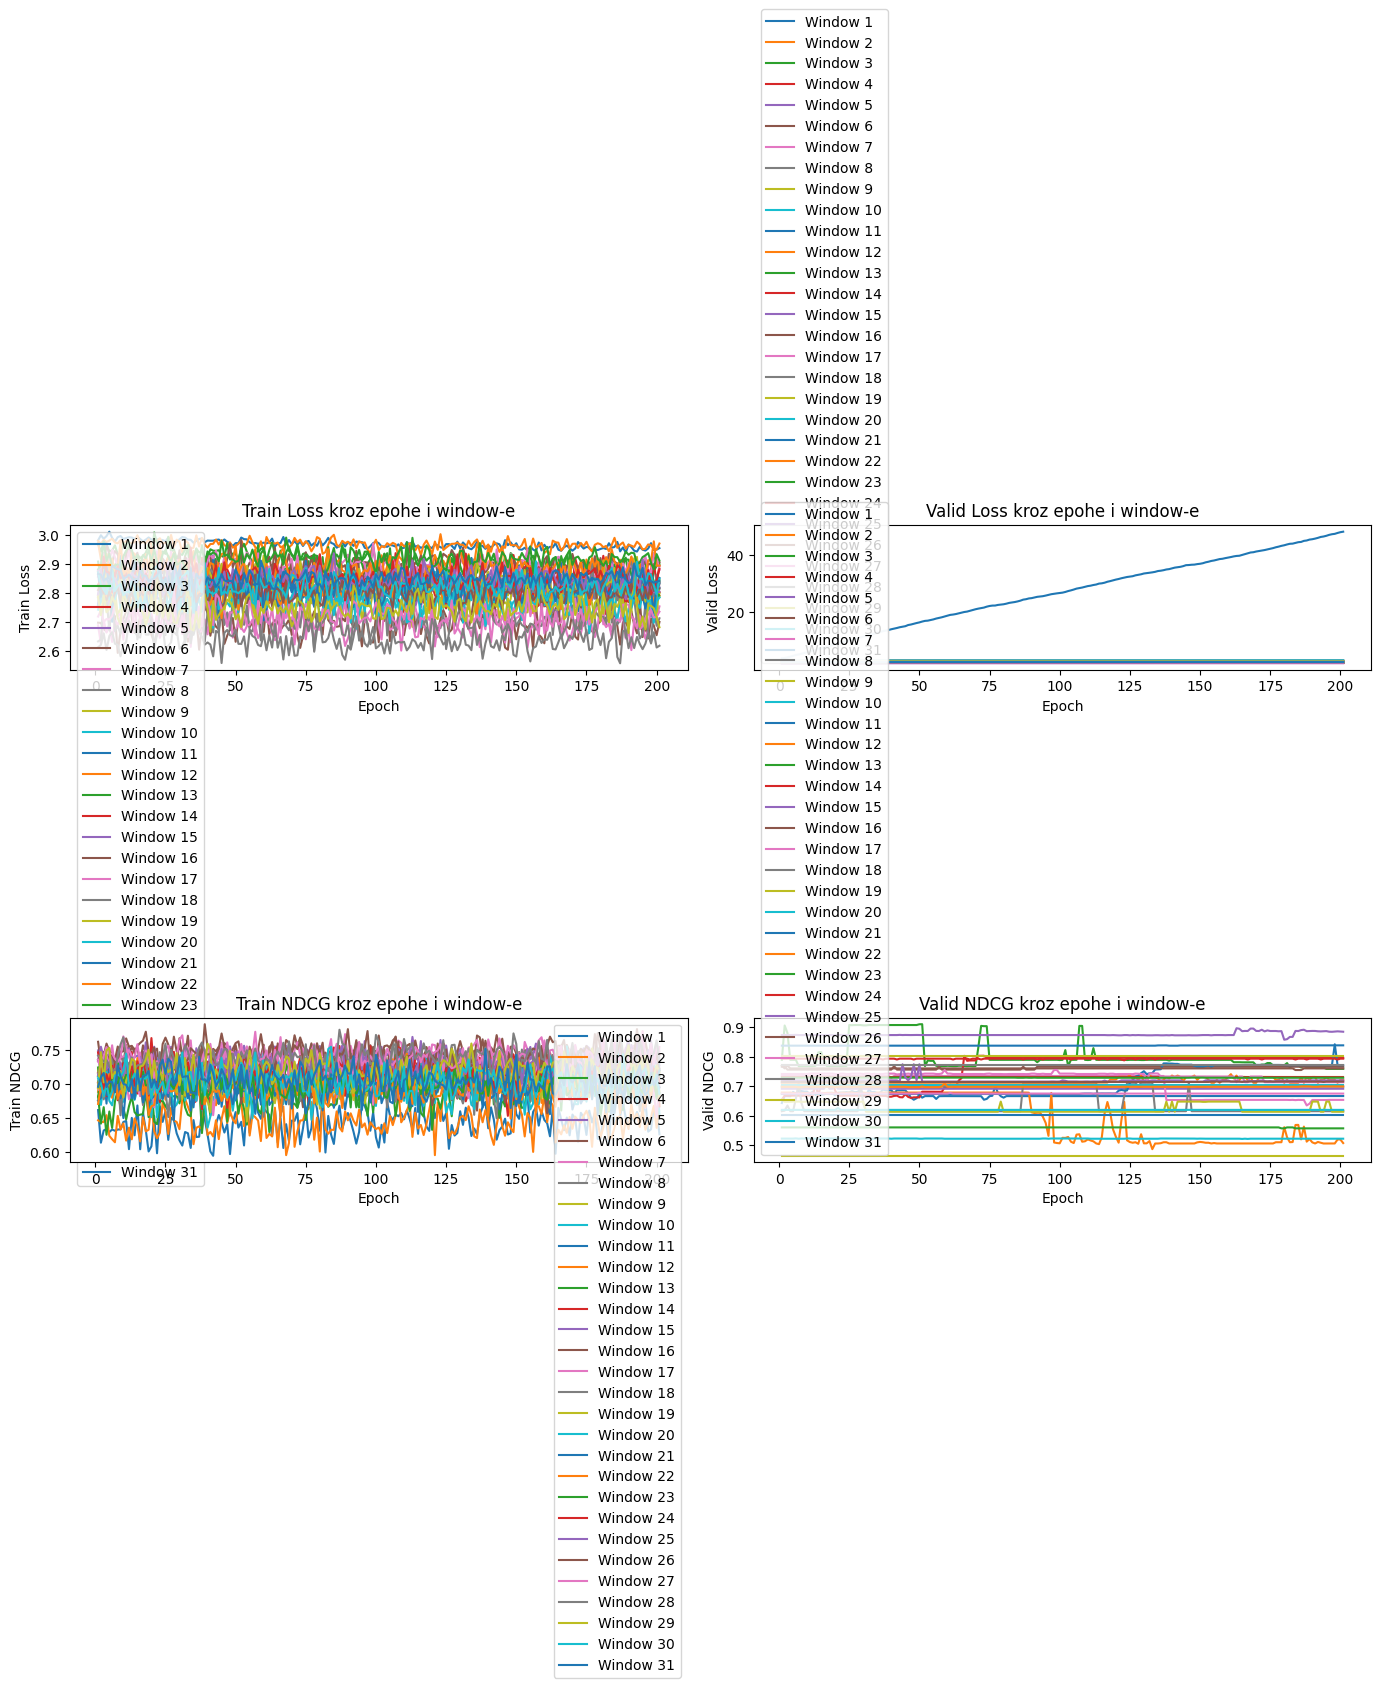

In [ ]:
# Plotovanje na kraju svih window-a
# Pretvaranje u numpy za lakše indeksiranje 
import numpy as np
all_train_losses = np.array(all_train_losses)    # shape = (num_windows, num_epochs)
all_valid_losses = np.array(all_valid_losses)
all_train_ndcgs = np.array(all_train_ndcgs)
all_valid_ndcgs = np.array(all_valid_ndcgs)

epochs = np.arange(1, num_epochs+1)
windows = np.arange(1, all_train_losses.shape[0]+1)

plt.figure(figsize=(14, 10))

# Plot train losses po epohama i prozorima
plt.subplot(2,2,1)
for i in range(all_train_losses.shape[0]):
    plt.plot(epochs, all_train_losses[i], label=f'Window {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Train Loss kroz epohe i window-e')
plt.legend()

# Plot valid losses
plt.subplot(2,2,2)
for i in range(all_valid_losses.shape[0]):
    plt.plot(epochs, all_valid_losses[i], label=f'Window {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Valid Loss')
plt.title('Valid Loss kroz epohe i window-e')
plt.legend()

# Plot train NDCG
plt.subplot(2,2,3)
for i in range(all_train_ndcgs.shape[0]):
    plt.plot(epochs, all_train_ndcgs[i], label=f'Window {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Train NDCG')
plt.title('Train NDCG kroz epohe i window-e')
plt.legend()

# Plot valid NDCG
plt.subplot(2,2,4)
for i in range(all_valid_ndcgs.shape[0]):
    plt.plot(epochs, all_valid_ndcgs[i], label=f'Window {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Valid NDCG')
plt.title('Valid NDCG kroz epohe i window-e')
plt.legend()

plt.tight_layout()
plt.show()


In [215]:
print(window_start)

120


In [216]:
len(dataset)

148

In [ ]:
race_index = 1  # koja trka se indeksira

with torch.no_grad():
    for batch_idx, (cat_features, num_tensor, target, drivers_num, position_quali) in enumerate(loader_test):
        if race_index // batch_size == batch_idx:
            sample_idx = race_index % batch_size  # indeks unutar batcha

            cat_features = {k: v.to(device) for k, v in cat_features.items()}
            num_tensor = num_tensor.to(device)
            target = target.to(device)

            output = model(cat_features, num_tensor).squeeze(-1)

            # Izvlacenje samo jedne trke iz batcha
            scores = output[sample_idx].cpu().numpy()
            true_ranks = target[sample_idx].cpu().numpy()
            quali_pos = position_quali[sample_idx].numpy()
            driver_ids = drivers_num[sample_idx].numpy()

            # Sortiraj po predikcijama
            pred_order = scores.argsort()

            print(f"Poređenje za trku #{race_index}:\n")
            print(f"{'Poz':<5}{'Vozač':<10}{'Stvarna':<10}{'Predviđena':<12}{'Kvalifikacije':<15}")
            for pos, idx in enumerate(pred_order):
                print(f"{pos+1:<5}{driver_ids[idx]:<10}{true_ranks[idx]:<10}{pos+1:<12}{quali_pos[idx]:<15}")
            break


Poređenje za trku #1:

Poz  Vozač     Stvarna   Predviđena  Kvalifikacije  
1    11        4.0       1           17             
2    43        9.0       2           12             
3    18        10.0      3           11             
4    14        3.0       4           18             
5    30        5.0       5           16             
6    20        14.0      6           7              
7    33        15.0      7           6              
8    44        17.0      8           4              
9    16        18.0      9           3              
10   55        20.0      10          1              
11   4         19.0      11          2              
12   63        16.0      12          5              
13   81        13.0      13          8              
14   23        2.0       14          19             
15   31        8.0       15          13             
16   10        11.0      16          10             
17   22        1.0       17          20             
18   27        12.0    